# Data transformation 🧬

In this notebook we uses data transformation such as ordinalEncoder and OneHotEncoder which is necessary to ensure that data is accurate, consistent, and in a usable format for analysis and decision-making.

can u fill the ??

## Importing Libraries 🛠
We will start by importing the necessary libraries that we will be using throughout the notebook.

- `pandas` - for data manipulation and analysis
- `numpy` - for numerical operations
- `matplotlib` - for data visualization
- `seaborn` - for advanced data visualization
- `OneHotEncoder` - for categorical encoding
- `ColumnTransformer` - for column-wise transformation


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

## Loading Data 📁

Next, we will load the dataset using pandas read_parquet function.

In [2]:
df = pd.read_csv("./../data/filtered_diamonds.csv")
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
0,1638147,CUSHION,0.549805,SI2,E,EX,EX,VG,N,1378.65,5.050781,4.351562,2.939453
1,1630155,CUSHION,0.500000,VVS1,FANCY,EX,EX,VG,F,1379.74,4.601562,4.308594,2.919922
2,1612606,CUSHION,0.509766,VS2,H,EX,EX,VG,N,1380.19,4.710938,4.351562,2.939453
3,1638140,CUSHION,0.500000,VS2,H,EX,EX,VG,N,1380.61,4.910156,4.261719,2.880859
4,1536093,CUSHION,0.529785,SI1,D,EX,VG,VG,N,1383.13,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5890,1751206,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.10,5.000000,5.039062,3.179688
5891,1773024,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.10,5.031250,5.058594,3.160156
5892,1789435,ROUND,0.500000,VS2,D,VG,EX,VG,N,2453.20,4.929688,4.960938,3.189453
5893,1774887,ROUND,0.520020,SI1,H,EX,EX,EX,N,2453.41,5.109375,5.128906,3.199219


## Data Exploration 🔎

Let's explore the data by checking the columns and their data types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5895 non-null   object 
 1   Shape         5895 non-null   object 
 2   Weight        5895 non-null   float64
 3   Clarity       5895 non-null   object 
 4   Colour        5895 non-null   object 
 5   Cut           5895 non-null   object 
 6   Polish        5895 non-null   object 
 7   Symmetry      5895 non-null   object 
 8   Fluorescence  5895 non-null   object 
 9   Price         5895 non-null   float64
 10  Length        5895 non-null   float64
 11  Width         5895 non-null   float64
 12  Depth         5895 non-null   float64
dtypes: float64(5), object(8)
memory usage: 598.8+ KB


## Remove unnecessary column 🔽

We remove `Id` using drop method

In [4]:
df.drop(['Id'], axis = 1, inplace = True) 

## Encode ordinal data 🔢

Using `ordinal_converter` function we can convert ordinal data into int type

In [5]:
def ordinal_converter(data, order):
    nums = list(range(len(order)))
    map = dict(zip(order, nums))
    return data.replace(map)

Applying this function to all ordinal data (ie Fluorescence, Symmetry, Polish, Cut, Colour and Clarity)

In [6]:
df.Fluorescence = ordinal_converter(df.Fluorescence, ['N', 'M', 'F', 'SL', 'ST', 'VS', 'VSL'])

In [7]:
df.Symmetry = ordinal_converter(df.Symmetry, ['FR', 'GD', 'VG', 'EX'])

In [8]:
df.Polish = ordinal_converter(df.Polish, ['FR', 'GD', 'VG', 'EX'])

In [9]:
df.Cut = ordinal_converter(df.Cut, ['FR', 'GD', 'VG', 'EX'])

In [10]:
df.Colour = ordinal_converter(
    df.Colour,
    [
        "Y-Z",
        "W-X",
        "W",
        "U-V",
        "S-T",
        "Q-R",
        "O-P",
        "O",
        "N",
        "M",
        "L",
        "K",
        "J",
        "I",
        "H",
        "G",
        "F",
        "E",
        "D",
        "FANCY",
    ],
)

In [11]:
df.Clarity = ordinal_converter(df.Clarity,['I3', 'I2', 'I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'])

Checking the dataframe

In [12]:
df

,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
0,CUSHION,0.549805,3,17,3,3,2,0,1378.65,5.050781,4.351562,2.939453
1,CUSHION,0.500000,8,19,3,3,2,2,1379.74,4.601562,4.308594,2.919922
2,CUSHION,0.509766,5,14,3,3,2,0,1380.19,4.710938,4.351562,2.939453
3,CUSHION,0.500000,5,14,3,3,2,0,1380.61,4.910156,4.261719,2.880859
4,CUSHION,0.529785,4,18,3,2,2,0,1383.13,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...
5890,ROUND,0.500000,4,17,3,3,3,0,2453.10,5.000000,5.039062,3.179688
5891,ROUND,0.500000,4,17,3,3,3,0,2453.10,5.031250,5.058594,3.160156
5892,ROUND,0.500000,5,18,2,3,2,0,2453.20,4.929688,4.960938,3.189453
5893,ROUND,0.520020,4,14,3,3,3,0,2453.41,5.109375,5.128906,3.199219


## Encode nominal data 🔡

Using OneHotEncoder we can encode nominal data (ie Shape)

In [13]:
model_OHE = ColumnTransformer(
    [('Shape_encoder', OneHotEncoder(),['Shape'])],
    remainder = 'passthrough'
    )
transform = model_OHE.fit_transform(df)
transform

array([[1.       , 0.       , 0.       , ..., 5.0507812, 4.3515625,
        2.9394531],
       [1.       , 0.       , 0.       , ..., 4.6015625, 4.3085938,
        2.9199219],
       [1.       , 0.       , 0.       , ..., 4.7109375, 4.3515625,
        2.9394531],
       ...,
       [0.       , 0.       , 0.       , ..., 4.9296875, 4.9609375,
        3.1894531],
       [0.       , 0.       , 0.       , ..., 5.109375 , 5.1289062,
        3.1992188],
       [0.       , 0.       , 0.       , ..., 5.0898438, 5.1289062,
        3.1191406]])

Convert array to dataframe

In [14]:
transform_df = pd.DataFrame(transform, columns=['Shape_CUSHION', 'Shape_EMERALD', 'Shape_HEART', 'Shape_MARQUISE', 'Shape_OVAL', 'Shape_PEAR', 'Shape_PRINCESS', 'Shape_ROUND','Weight', 'Clarity', 'Colour', 'Cut', 'Polish', 'Symmetry', 'Fluorescence', 'Price', 'Length','Width', 'Depth'])
transform_df

,Shape_CUSHION,Shape_EMERALD,Shape_HEART,Shape_MARQUISE,Shape_OVAL,Shape_PEAR,Shape_PRINCESS,Shape_ROUND,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.549805,3.0,17.0,3.0,3.0,2.0,0.0,1378.65,5.050781,4.351562,2.939453
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,8.0,19.0,3.0,3.0,2.0,2.0,1379.74,4.601562,4.308594,2.919922
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.509766,5.0,14.0,3.0,3.0,2.0,0.0,1380.19,4.710938,4.351562,2.939453
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,5.0,14.0,3.0,3.0,2.0,0.0,1380.61,4.910156,4.261719,2.880859
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.529785,4.0,18.0,3.0,2.0,2.0,0.0,1383.13,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000,4.0,17.0,3.0,3.0,3.0,0.0,2453.10,5.000000,5.039062,3.179688
5891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000,4.0,17.0,3.0,3.0,3.0,0.0,2453.10,5.031250,5.058594,3.160156
5892,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.500000,5.0,18.0,2.0,3.0,2.0,0.0,2453.20,4.929688,4.960938,3.189453
5893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.520020,4.0,14.0,3.0,3.0,3.0,0.0,2453.41,5.109375,5.128906,3.199219


Get info about the `transform_df` dataframe

In [15]:
transform_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Shape_CUSHION   5895 non-null   float64
 1   Shape_EMERALD   5895 non-null   float64
 2   Shape_HEART     5895 non-null   float64
 3   Shape_MARQUISE  5895 non-null   float64
 4   Shape_OVAL      5895 non-null   float64
 5   Shape_PEAR      5895 non-null   float64
 6   Shape_PRINCESS  5895 non-null   float64
 7   Shape_ROUND     5895 non-null   float64
 8   Weight          5895 non-null   float64
 9   Clarity         5895 non-null   float64
 10  Colour          5895 non-null   float64
 11  Cut             5895 non-null   float64
 12  Polish          5895 non-null   float64
 13  Symmetry        5895 non-null   float64
 14  Fluorescence    5895 non-null   float64
 15  Price           5895 non-null   float64
 16  Length          5895 non-null   float64
 17  Width           5895 non-null   f

## Type checking 🧪

Using `convert_dtypes` to change the appropriate type of data 

In [16]:
transform_df = transform_df.convert_dtypes()

## Rearranging columns 🔀

Rearranging the columns so that all int type will be first the float the target (ie Price) 

In [17]:
cols = [
    "Shape_CUSHION",
    "Shape_EMERALD",
    "Shape_HEART",
    "Shape_MARQUISE",
    "Shape_OVAL",
    "Shape_PEAR",
    "Shape_PRINCESS",
    "Shape_ROUND",
    "Clarity",
    "Colour",
    "Cut",
    "Polish",
    "Symmetry",
    "Fluorescence",
    "Weight",
    "Length",
    "Width",
    "Depth",
    "Price"
]

In [18]:
transform_df = transform_df[cols]

Get info about the `transform_df` dataframe

In [19]:
transform_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Shape_CUSHION   5895 non-null   Int64  
 1   Shape_EMERALD   5895 non-null   Int64  
 2   Shape_HEART     5895 non-null   Int64  
 3   Shape_MARQUISE  5895 non-null   Int64  
 4   Shape_OVAL      5895 non-null   Int64  
 5   Shape_PEAR      5895 non-null   Int64  
 6   Shape_PRINCESS  5895 non-null   Int64  
 7   Shape_ROUND     5895 non-null   Int64  
 8   Clarity         5895 non-null   Int64  
 9   Colour          5895 non-null   Int64  
 10  Cut             5895 non-null   Int64  
 11  Polish          5895 non-null   Int64  
 12  Symmetry        5895 non-null   Int64  
 13  Fluorescence    5895 non-null   Int64  
 14  Weight          5895 non-null   Float64
 15  Length          5895 non-null   Float64
 16  Width           5895 non-null   Float64
 17  Depth           5895 non-null   F

## Correlation Matrix of Diamond Features 🔢

In this test, we will determine correlation relation for all numeric feature

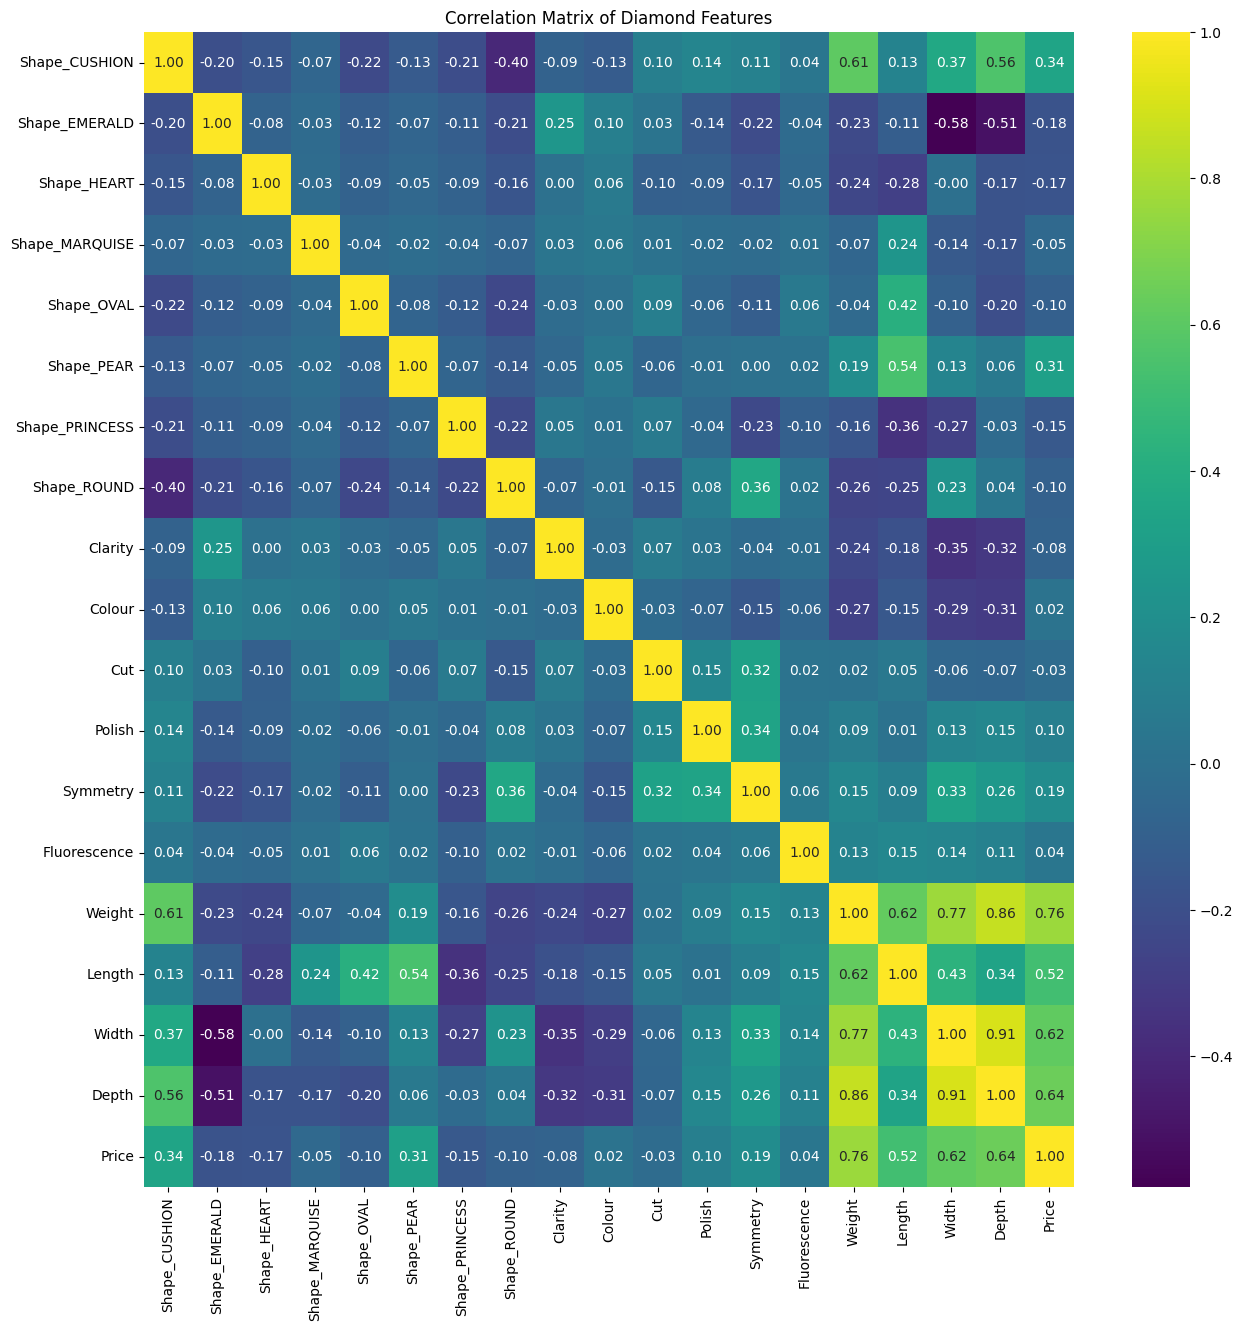

In [20]:
plt.figure(figsize=(15,15))
sns.heatmap(transform_df.corr(numeric_only = True), annot=True, fmt=".2f", cmap="viridis")
plt.title('Correlation Matrix of Diamond Features')
plt.show()

## Saving the optimized dataframe 📎

Save the dataframe in `./../data/transform_diamonds.csv` without index

In [21]:
transform_df.to_csv("./../data/transform_diamonds.csv", index=False)

Also saving in parquet file using BROTLI compression and this will be save at `./../data/clean_diamonds.br`

In [22]:
transform_df.to_parquet("./../data/transform_diamonds.br", compression="BROTLI")

## Conclusion 🎉

In this notebook, we performed data transformations the diamonds dataset. We started by importing necessary libraries, loading the dataset, and data exploration by checking the columns and their data types. We then removed unnecessary columns.

We also performed ordinal encoder and OneHotEncoder to our dataset.

Finally, we also apply type checking and rearranging columns and saved it in csv as well as parquet format

Overall, these steps helped us to transform the dataset, making it ready for further modeling.